# SPARC Example 11: THINGS vs SPARC Cross-Survey Comparison

**EPS Research RAG Astrophysics Corpus — Unified HI Corpus v7.0**

14 galaxies appear in both THINGS and SPARC.
THINGS provides high-resolution VLA tilted-ring fits;
SPARC provides full baryonic decomposition at Spitzer 3.6μm.
The corpus crossmatch index enables direct comparison.

**Important note on corpus fidelity:** The `rotation_curve_corpus_v7_flat.csv` and `rotation_curve_corpus_v7.json` are **full-fidelity** — not a summary or veneer. The CSV contains every kinematic parameter published by Lelli et al. (2016) including per-galaxy inclination, distance uncertainties, mass-to-light ratios, and rotation curve statistics. The JSON adds full per-ring data: Vobs, Vgas, Vdisk, Vbul, errV at every radial point. This is the complete published dataset in a single machine-readable file.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19563417  
**Source:** Lelli, McGaugh & Schombert (2016), AJ 152, 157  
**Dependencies:** Python 3, numpy, matplotlib, csv (standard library only)

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'rotation_curve_corpus_v7.json': 'https://zenodo.org/records/19563417/files/rotation_curve_corpus_v7.json',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import csv
import matplotlib.pyplot as plt

rows = []
with open('rotation_curve_corpus_v7_flat.csv') as f:
    for r in csv.DictReader(f):
        rows.append(r)

sparc_names  = {r['galaxy'] for r in rows if r['survey'] == 'SPARC'}
things_names = {r['galaxy'] for r in rows if r['survey'] == 'THINGS'}
overlap      = sparc_names & things_names

print(f"SPARC galaxies:  {len(sparc_names)}")
print(f"THINGS galaxies: {len(things_names)}")
print(f"Overlap:         {len(overlap)} galaxies\n")

sparc_vmax, things_vmax, names = [], [], []
for name in sorted(overlap):
    sr = next((r for r in rows if r['galaxy']==name and r['survey']=='SPARC'
               and r['vrot_max_kms']), None)
    tr = next((r for r in rows if r['galaxy']==name and r['survey']=='THINGS'
               and r['vrot_max_kms']), None)
    if sr and tr:
        sv, tv = float(sr['vrot_max_kms']), float(tr['vrot_max_kms'])
        sparc_vmax.append(sv)
        things_vmax.append(tv)
        names.append(name)
        print(f"  {name:<15} SPARC={sv:.0f}  THINGS={tv:.0f} km/s")

SPARC galaxies:  175
THINGS galaxies: 34
Overlap:         14 galaxies

  DDO154          SPARC=48  THINGS=50 km/s
  IC2574          SPARC=68  THINGS=78 km/s
  NGC2366         SPARC=54  THINGS=58 km/s
  NGC2403         SPARC=136  THINGS=144 km/s
  NGC2841         SPARC=323  THINGS=324 km/s
  NGC2903         SPARC=216  THINGS=215 km/s
  NGC2976         SPARC=89  THINGS=86 km/s
  NGC3198         SPARC=157  THINGS=159 km/s
  NGC3521         SPARC=220  THINGS=233 km/s
  NGC5055         SPARC=206  THINGS=212 km/s
  NGC6946         SPARC=181  THINGS=224 km/s
  NGC7331         SPARC=257  THINGS=268 km/s
  NGC7793         SPARC=116  THINGS=118 km/s


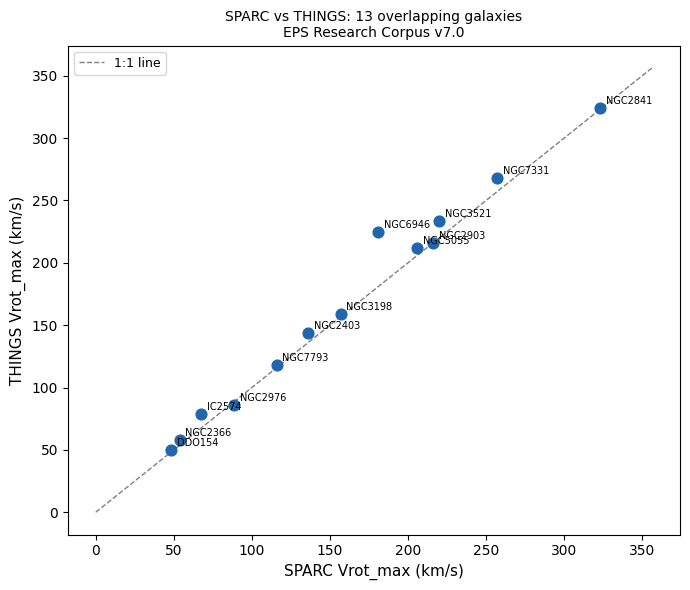

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sparc_vmax, things_vmax, s=60, color='#2166ac', zorder=3)
for i, name in enumerate(names):
    ax.annotate(name, (sparc_vmax[i], things_vmax[i]),
                textcoords='offset points', xytext=(4, 3), fontsize=7)
lim = [0, max(sparc_vmax + things_vmax) * 1.1]
ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.5, label='1:1 line')
ax.set_xlabel('SPARC Vrot_max (km/s)', fontsize=11)
ax.set_ylabel('THINGS Vrot_max (km/s)', fontsize=11)
ax.set_title(f'SPARC vs THINGS: {len(names)} overlapping galaxies\n'
             'EPS Research Corpus v7.0', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ex11_things_vs_sparc.png', dpi=150, bbox_inches='tight')
plt.show()